# ✋ Hand Gesture Classification — Notebook 1: Data Acquisition & Feature Extraction

## 📘 1. Tổng quan dự án

### 🎯 Mục tiêu
Chuyển đổi tập hợp các hình ảnh cử chỉ tay thô thành dữ liệu số (Landmarks). Đây là bước quan trọng nhất trong pipeline để chuẩn bị dữ liệu cho các mô hình khai phá dữ liệu (Data Mining).

*   **Đầu vào:** Ảnh cử chỉ tay (.jpg, .png).
*   **Đầu ra:** File `hand_gestures.csv` chứa tọa độ 21 điểm mốc (landmarks) của bàn tay.

### 🧠 Pipeline dự án

Gesture Images  
↓  
Hand Landmark Extraction (MediaPipe)  
↓  
Dataset Construction (42 features)  
↓  
Exploratory Data Analysis (EDA)  
↓  
Preprocessing  
↓  
Classification Model (XGBoost)

### 📑 Mục lục
1. [⚙️ Thiết lập Môi trường](#1.-Thiết-lập-Môi-trường)
2. [📁 Khám phá cấu trúc Dữ liệu thô](#2.-Khám-phá-Dữ-liệu-thô)
3. [📊 Thống kê và Trực quan hóa Ảnh mẫu](#3.-Thống-kê-và-Trực-quan-hóa)
4. [🧬 Trích xuất đặc trưng với MediaPipe](#4.-Trích-xuất-đặc-trưng)
5. [💾 Kiểm tra Dữ liệu sau trích xuất](#5.-Kiểm-tra-Dữ-liệu)

---

## <a id="1.-Thiết-lập-Môi-trường"></a>1. ⚙️ Thiết lập Môi trường
Trong phần này chúng ta sẽ:
- Import các thư viện cần thiết
- Thiết lập các tham số chung cho notebook

In [3]:
import os
import sys
sys.path.append("../")

# Xử lý dữ liệu
import cv2
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

from motion_detection.scripts.create_csv import run_extraction

import warnings
warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

---

## <a id="2.-Khám-phá-Dữ-liệu-thô"></a>2. 📁 Khám phá cấu trúc Dữ liệu thô

Dataset nằm trong thư mục: `data/static/`

Một số gesture chứa ảnh trực tiếp, trong khi một số gesture chứa các sub-folder.=

In [4]:
DATA_DIR = "data/static"

gestures = sorted(os.listdir(DATA_DIR))

print(f"Danh sách các cử chỉ phát hiện được: {gestures}")

Danh sách các cử chỉ phát hiện được: ['1-one', '2-two', '3-three', '4-open_close', '5-rotate', '7-victory']


### 📝 Nhận xét:
* Dữ liệu thô đã được phân loại theo thư mục nhãn (Label-based directory).
* Cần sử dụng thuật toán duyệt đệ quy (Recursive walk) để đảm bảo lấy hết ảnh trong các sub-folders.

---

## <a id="3.-Thống-kê-và-Trực-quan-hóa"></a>3. 📊 Thống kê và Trực quan hóa

### 3.1 Đếm số lượng mẫu của từng Class

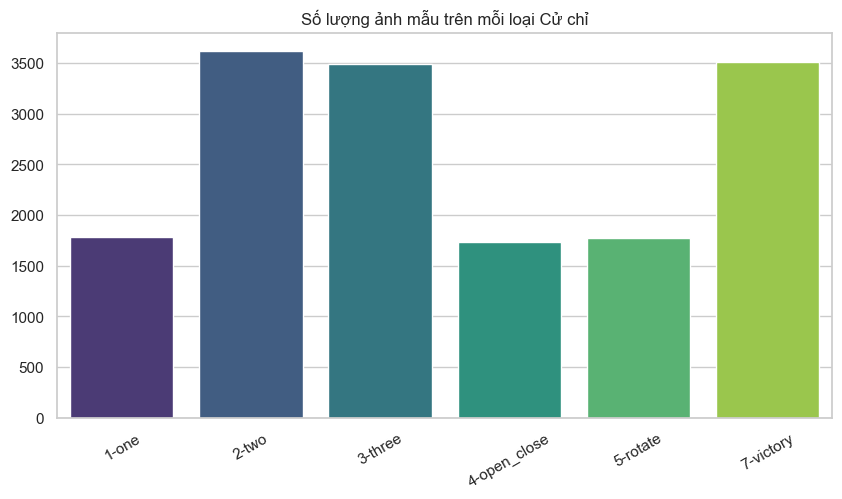

In [5]:
image_counts = {}
for gesture in gestures:
    gesture_path = os.path.join(DATA_DIR, gesture)
    count = sum([len(files) for r, d, files in os.walk(gesture_path) if any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in files)])
    image_counts[gesture] = count

# Vẽ biểu đồ cột
plt.figure(figsize=(10, 5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="viridis")
plt.title("Số lượng ảnh mẫu trên mỗi loại Cử chỉ")
plt.xticks(rotation=30)
plt.show()

#### 📝 Nhận xét:
* **Sự phân tán**: Biểu đồ giúp nhận diện nhanh các class bị thiếu hụt dữ liệu (Ví dụ: 1-one thường có ít ảnh hơn 2-two).
* **Sự mất cân bằng**: Nếu sự chênh lệch quá lớn, ta sẽ cần lưu ý khi chia tập Train/Test ở Notebook sau.

### 3.2 Trực quan hóa các ảnh mẫu (Sample Visualization)

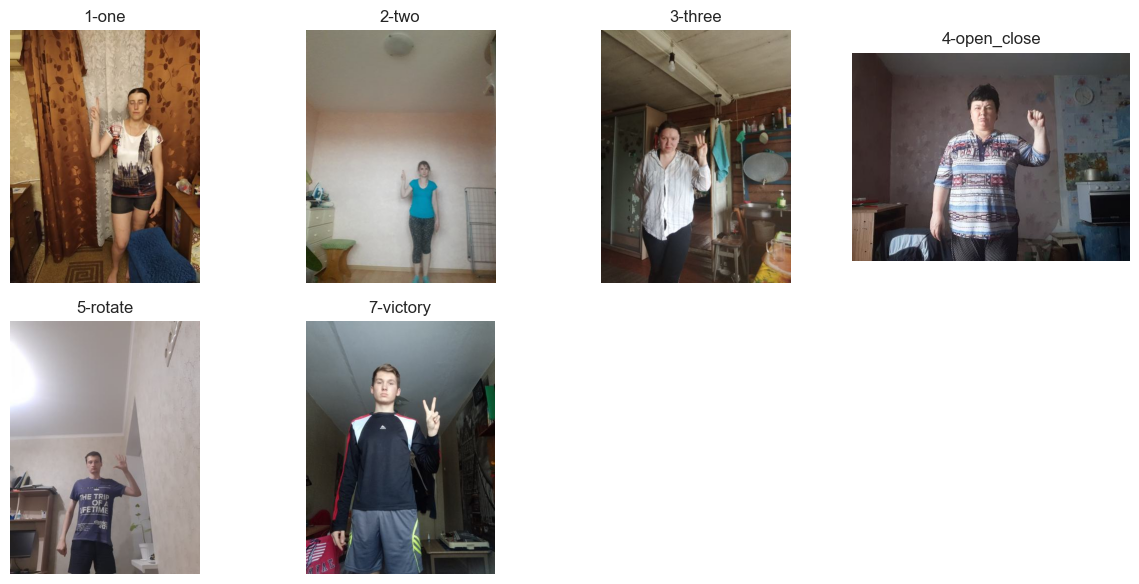

In [6]:
plt.figure(figsize=(12,6))

i = 1

for gesture in gestures:

    gesture_path = os.path.join(DATA_DIR, gesture)

    images = []

    for root, dirs, files in os.walk(gesture_path):
        for file in files:
            if file.lower().endswith((".jpg",".png",".jpeg")):
                images.append(os.path.join(root,file))

    if len(images) == 0:
        continue

    img_path = random.choice(images)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,4,i)
    plt.imshow(img)
    plt.title(gesture)
    plt.axis("off")

    i += 1

plt.tight_layout()
plt.show()

#### 📝 Nhận xét:
* **Chất lượng ảnh**: Ảnh có độ phân giải và điều kiện ánh sáng khác nhau.
* **Đặc điểm**: Một số ảnh có hậu cảnh phức tạp, điều này sẽ kiểm chứng khả năng trích xuất landmark của bộ lọc MediaPipe.

---

## <a id="4.-Trích-xuất-đặc-trưng"></a>4. 🧬 Trích xuất đặc trưng với MediaPipe

Trong bước này, chúng ta sử dụng **MediaPipe Hands** sẽ chuyển đổi từ dữ liệu phi cấu trúc (Pixel) sang dữ liệu có cấu trúc (Tọa độ). Chúng ta trích xuất 21 điểm mốc, mỗi điểm có tọa độ *(x,y)*, tạo thành **42 đặc trưng** đầu vào.

### 4.1 Thực hiện script trích xuất đặc trưng

In [7]:
print("🚀 Đang bắt đầu trích xuất Landmarks... Vui lòng đợi.")

run_extraction(
    "data/static",
    "motion_detection/models/hand_gestures.csv"
)

🚀 Đang bắt đầu trích xuất Landmarks... Vui lòng đợi.

--- Processing label: 1-one ---

--- Processing label: 2-two ---

--- Processing label: 3-three ---

--- Processing label: 4-open_close ---

--- Processing label: 5-rotate ---

--- Processing label: 7-victory ---

Hoàn thành quá trình trích xuất
Tổng số ảnh: 15902
Hoàn thành việc nhận diện: 14467
Đã lưu vào: motion_detection/models/hand_gestures.csv


#### 📝 Nhận xét:
* **Cơ chế**: MediaPipe tự động chuẩn hóa tọa độ ảnh về khoảng [0,1].
* **Xử lý lỗi**: Những ảnh không nhận diện được bàn tay sẽ bị bỏ qua để đảm bảo tính sạch của dataset.

---

## <a id="5.-Kiểm-tra-Dữ-liệu"></a>5. 💾 Kiểm tra Dữ liệu sau trích xuất

In [8]:
df_result = pd.read_csv("motion_detection/models/hand_gestures.csv")

display("🔎 5 dòng đầu tiên của Dataset:")
display(df_result.head())

print(f"\n📊 Tổng số mẫu dữ liệu đã trích xuất thành công: {len(df_result)}")

'🔎 5 dòng đầu tiên của Dataset:'

,p0_x,p0_y,p1_x,p1_y,p2_x,p2_y,p3_x,p3_y,p4_x,p4_y,...,p16_y,p17_x,p17_y,p18_x,p18_y,p19_x,p19_y,p20_x,p20_y,label
0,0.0,0.0,0.371055,-0.195041,0.500530,-0.377704,0.606191,-0.502968,0.677489,-0.612328,...,-0.374042,0.081630,-0.352000,0.484943,-0.397402,0.499543,-0.328662,0.393399,-0.297588,1-one
1,0.0,0.0,0.111710,0.001854,0.217886,-0.152971,0.230500,-0.314417,0.146640,-0.360136,...,-0.112532,-0.051857,-0.445407,-0.031375,-0.467644,-0.011079,-0.316914,0.007865,-0.199147,1-one
2,0.0,0.0,-0.194745,-0.077441,-0.356909,-0.205940,-0.401999,-0.335197,-0.312623,-0.437183,...,-0.200739,0.282746,-0.407561,0.143728,-0.390566,0.069926,-0.274221,0.053463,-0.202829,1-one
3,0.0,0.0,-0.110244,-0.116823,-0.187971,-0.270933,-0.177413,-0.421465,-0.118389,-0.537235,...,-0.321677,0.113905,-0.422739,0.101910,-0.504413,0.076407,-0.380565,0.069560,-0.328975,1-one
4,0.0,0.0,0.201101,-0.115647,0.296182,-0.290313,0.266590,-0.424632,0.157655,-0.488081,...,-0.275580,-0.186903,-0.393544,-0.160508,-0.458688,-0.103403,-0.360976,-0.075393,-0.286336,1-one



📊 Tổng số mẫu dữ liệu đã trích xuất thành công: 14467


### 📝 Nhận xét cuối cùng:
* Dữ liệu bây giờ đã ở dạng bảng (Tabular data), sẵn sàng cho các phân tích thống kê chuyên sâu (EDA) và huấn luyện mô hình.
* Mỗi dòng đại diện cho một "bản chụp" khung xương bàn tay, loại bỏ hoàn toàn các yếu tố nhiễu từ màu sắc hay hậu cảnh của ảnh gốc.